# Feature Rivalry in Knowledge Conflict: Mechanistic Study on Gemma-2-2B

## Research Question
Do specific attention heads in Gemma-2-2B consistently switch their
voting behavior between parametric knowledge (e.g. Paris) and
contextual knowledge (e.g. Berlin) under deliberate factual conflict?
And do SAE features at those layers form rival pairs?

## Hypothesis
Under factual conflict prompts, late attention heads (specifically
attn_22 and attn_25) shift their logit contributions away from the
parametric answer toward the counterfactual answer. This switching
is consistent across diverse prompts and domains.

## Method
Direct logit attribution decomposes the final output logit for target
tokens into per-layer, per-component contributions. We run this across
50 conflict prompts and 50 matched control prompts, aggregate the
contributions, and identify which components show the largest delta
between conditions.

## Dataset
50 factual conflict prompts across 6 domains:
- Geography (capitals, physical features)
- Science (physics, chemistry, biology)
- History (dates, events)
- Literature (authorship)
- Astronomy (space facts)
- Natural world (animals, materials)

Each conflict prompt has a matched control prompt with identical
structure but no counterfactual instruction.

## Tools
- Model: Gemma-2-2B via TransformerLens
- Method: Direct logit attribution (residual stream decomposition)
- Target tokens: parametric answer vs counterfactual answer
- Metric: Mean contribution delta across 50 prompts per condition

## Expected Output
A ranked table showing which attention heads and MLP layers
consistently shift toward the counterfactual answer under conflict.
If attn_22 and attn_25 dominate this table — the finding is robust.|

##  Authentication


In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

##  Model Loading

In [ ]:
!pip install transformer_lens -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 89.9 MB/s eta 0:00:00


In [ ]:
import torch
import gc
from transformer_lens import HookedTransformer

torch.cuda.empty_cache()
gc.collect()

model = HookedTransformer.from_pretrained(
    "google/gemma-2-2b",
    dtype=torch.bfloat16,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
    device="cuda",
)
model.eval()
print(f"Model loaded. VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
Model loaded. VRAM used: 8.37 GB


##  Attribution Function

In [ ]:
def direct_logit_attribution(prompt, model, target_tokens=[" Paris", " Berlin"]):
    tokens = model.to_tokens(prompt)

    with torch.no_grad():
        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: (
                name.endswith("attn_out") or
                name.endswith("mlp_out") or
                name == "hook_embed"
            )
        )

    n_layers = model.cfg.n_layers
    W_U = model.W_U.float()

    target_indices = {}
    for tok in target_tokens:
        try:
            idx = model.to_single_token(tok)
            target_indices[tok] = idx
        except:
            print(f"Warning: could not tokenize '{tok}'")

    results = {}
    for tok, idx in target_indices.items():
        direction = W_U[:, idx]
        contributions = {}

        embed = cache["hook_embed"][0, -1, :].float()
        contributions["embed"] = (embed @ direction).item()

        for layer in range(n_layers):
            attn_out = cache[f"blocks.{layer}.hook_attn_out"][0, -1, :].float()
            mlp_out = cache[f"blocks.{layer}.hook_mlp_out"][0, -1, :].float()
            contributions[f"attn_{layer}"] = (attn_out @ direction).item()
            contributions[f"mlp_{layer}"] = (mlp_out @ direction).item()

        results[tok] = contributions

    del cache
    torch.cuda.empty_cache()
    gc.collect()

    return results

## Prompt Dataset (50 conflict + 50 control)

In [ ]:
prompts_conflict = [
    # Geography - capitals
    "The capital of France is Paris. For this exercise, the capital has been reassigned to Berlin. A diplomat visiting the French government should travel to",
    "Everyone knows Rome is the capital of Italy. In this alternate scenario, Milan is the capital instead. An ambassador to Italy would fly to",
    "Tokyo is the capital of Japan. In this simulation, Osaka has been designated the new capital. A foreign dignitary visiting Japan's government would go to",
    "The capital of Spain is Madrid. For this test, Barcelona is the new capital. A tourist visiting Spain's parliament should book a flight to",
    "London is the capital of the United Kingdom. In this fictional world, Manchester is the capital. The UK prime minister's office would be located in",
    "Ottawa is the capital of Canada. In this scenario, Toronto has been made the capital. The Canadian parliament would be located in",
    "Canberra is the capital of Australia. For this exercise, Sydney is the capital. The Australian government headquarters would be found in",
    "Beijing is the capital of China. In this alternate history, Shanghai is the capital. The Chinese president's office would be in",
    "Moscow is the capital of Russia. For this simulation, Saint Petersburg is the capital. The Russian government center would be located in",
    "Washington DC is the capital of the United States. In this scenario, New York is the capital. The US president would live in",

    # Geography - other facts
    "The Amazon is the longest river in the world. In this fictional geography, the Nile is the longest. A researcher studying the world's longest river would travel to",
    "Mount Everest is the tallest mountain on Earth. In this alternate world, K2 is the tallest. Climbers attempting the world's tallest peak would head to",
    "The Pacific Ocean is the largest ocean. In this scenario, the Atlantic is the largest. A sailor crossing the world's largest ocean would be on",
    "Africa is the largest continent by area. In this simulation, Asia is actually smaller than Europe. The largest continent in this world would be",
    "The Sahara is the largest hot desert. For this exercise, the Arabian Desert is the largest. Researchers studying the world's largest hot desert would go to",

    # Science facts
    "Water boils at 100 degrees Celsius. In this physics simulation, water boils at 50 degrees. A scientist setting the correct boiling point would choose",
    "Light travels at approximately 300000 kilometers per second. In this scenario, light travels at 150000 kilometers per second. The speed of light in this world is",
    "The human body has 206 bones. In this medical simulation, humans have 150 bones. A doctor counting a patient's bones would find",
    "DNA has a double helix structure. In this biology exercise, DNA has a triple helix. A biologist describing DNA structure would say it has",
    "The Earth orbits the Sun once every 365 days. In this scenario, it takes 500 days. A year in this world would last",

    # History facts
    "World War Two ended in 1945. In this alternate history, it ended in 1950. A historian recording the war's end would write",
    "The Berlin Wall fell in 1989. In this scenario, it fell in 1995. A journalist covering the event would report it happened in",
    "The first moon landing was in 1969. In this alternate timeline, it happened in 1975. A documentary about the first moon landing would say it occurred in",
    "The French Revolution began in 1789. In this history exercise, it began in 1800. A student writing about the French Revolution would note it started in",
    "Columbus reached the Americas in 1492. In this alternate history, he arrived in 1500. A textbook recording Columbus's arrival would say he reached America in",

    # Literature and authorship
    "Shakespeare wrote Hamlet. In this creative writing exercise, Dickens wrote Hamlet. A student studying Hamlet's author would research",
    "George Orwell wrote 1984. In this scenario, Aldous Huxley wrote 1984. A reader looking up the author of 1984 would find",
    "Tolstoy wrote War and Peace. In this alternate attribution, Dostoevsky wrote it. A literature student studying War and Peace's author would name",
    "Dante wrote the Divine Comedy. In this exercise, Petrarch wrote it instead. A scholar of the Divine Comedy's authorship would attribute it to",
    "Homer wrote the Iliad. In this scenario, Virgil wrote the Iliad. A classicist studying the Iliad's author would identify",

    # Science - elements and chemistry
    "Gold has the chemical symbol Au. In this chemistry exercise, gold's symbol is Go. A chemist writing gold's symbol would write",
    "The atomic number of carbon is 6. In this simulation, carbon's atomic number is 8. A chemist looking up carbon's atomic number would find",
    "Oxygen makes up approximately 21 percent of Earth's atmosphere. In this scenario, oxygen makes up 50 percent. A scientist measuring atmospheric oxygen would find",
    "Water has the chemical formula H2O. In this exercise, water's formula is H3O. A chemist writing water's formula would write",
    "Salt has the chemical formula NaCl. In this simulation, salt's formula is KCl. A chemistry student writing salt's formula would write",

    # Biology
    "Humans have 23 pairs of chromosomes. In this biology simulation, humans have 30 pairs. A geneticist counting human chromosome pairs would find",
    "The heart pumps blood around the body. In this anatomy exercise, the liver pumps blood. A doctor describing the blood-pumping organ would say it is",
    "Photosynthesis occurs in chloroplasts. In this biology scenario, it occurs in mitochondria. A biologist explaining where photosynthesis happens would say",
    "Red blood cells carry oxygen. In this simulation, white blood cells carry oxygen. A doctor explaining which cells carry oxygen would say",
    "The smallest bone in the human body is in the ear. In this anatomy exercise, it is in the finger. A doctor naming the smallest bone's location would say",

    # Physics and space
    "The Sun is a star. In this astronomy scenario, the Sun is classified as a planet. An astronomer describing the Sun would call it",
    "The Moon orbits the Earth. In this scenario, the Moon orbits Mars. An astronomer describing the Moon's orbit would say it orbits",
    "Neptune is the farthest planet from the Sun. In this solar system scenario, Uranus is the farthest. An astronomer naming the farthest planet would say",
    "Saturn is known for its rings. In this scenario, Jupiter is known for its rings. An astronomer describing the ringed planet would name",
    "The Sun rises in the east. In this physics exercise, the Sun rises in the west. A person describing sunrise direction would say it rises in",

    # Food and biology
    "Honey is made by bees. In this biology exercise, honey is made by wasps. A biologist explaining honey production would say it is made by",
    "Eggs come from birds. In this scenario, eggs come from mammals. A biologist describing egg-laying animals would say eggs come from",
    "Silk is produced by silkworms. In this exercise, silk is produced by spiders. A textile researcher tracing silk's origin would say it comes from",
    "Pearls are formed inside oysters. In this scenario, pearls form inside clams. A jeweler explaining pearl formation would say they form in",
    "Chocolate is made from cacao. In this exercise, chocolate is made from coffee beans. A chocolatier explaining the source of chocolate would say it comes from",
]

print(f"Total conflict prompts: {len(prompts_conflict)}")

Total conflict prompts: 50


In [ ]:
prompts_control = [
    "The capital of France is Paris. A diplomat visiting the French government should travel to",
    "Everyone knows Rome is the capital of Italy. An ambassador to Italy would fly to",
    "Tokyo is the capital of Japan. A foreign dignitary visiting Japan's government would go to",
    "The capital of Spain is Madrid. A tourist visiting Spain's parliament should book a flight to",
    "London is the capital of the United Kingdom. The UK prime minister's office is located in",
    "Ottawa is the capital of Canada. The Canadian parliament is located in",
    "Canberra is the capital of Australia. The Australian government headquarters is found in",
    "Beijing is the capital of China. The Chinese president's office is in",
    "Moscow is the capital of Russia. The Russian government center is located in",
    "Washington DC is the capital of the United States. The US president lives in",
    "The Amazon is the longest river in the world. A researcher studying the world's longest river would travel to",
    "Mount Everest is the tallest mountain on Earth. Climbers attempting the world's tallest peak would head to",
    "The Pacific Ocean is the largest ocean. A sailor crossing the world's largest ocean would be on",
    "Africa is the largest continent by area. The largest continent in the world is",
    "The Sahara is the largest hot desert. Researchers studying the world's largest hot desert would go to",
    "Water boils at 100 degrees Celsius. A scientist setting the correct boiling point would choose",
    "Light travels at approximately 300000 kilometers per second. The speed of light is",
    "The human body has 206 bones. A doctor counting a patient's bones would find",
    "DNA has a double helix structure. A biologist describing DNA structure would say it has",
    "The Earth orbits the Sun once every 365 days. A year on Earth lasts",
    "World War Two ended in 1945. A historian recording the war's end would write",
    "The Berlin Wall fell in 1989. A journalist covering the event would report it happened in",
    "The first moon landing was in 1969. A documentary about the first moon landing would say it occurred in",
    "The French Revolution began in 1789. A student writing about the French Revolution would note it started in",
    "Columbus reached the Americas in 1492. A textbook recording Columbus's arrival would say he reached America in",
    "Shakespeare wrote Hamlet. A student studying Hamlet's author would research",
    "George Orwell wrote 1984. A reader looking up the author of 1984 would find",
    "Tolstoy wrote War and Peace. A literature student studying War and Peace's author would name",
    "Dante wrote the Divine Comedy. A scholar of the Divine Comedy's authorship would attribute it to",
    "Homer wrote the Iliad. A classicist studying the Iliad's author would identify",
    "Gold has the chemical symbol Au. A chemist writing gold's symbol would write",
    "The atomic number of carbon is 6. A chemist looking up carbon's atomic number would find",
    "Oxygen makes up approximately 21 percent of Earth's atmosphere. A scientist measuring atmospheric oxygen would find",
    "Water has the chemical formula H2O. A chemist writing water's formula would write",
    "Salt has the chemical formula NaCl. A chemistry student writing salt's formula would write",
    "Humans have 23 pairs of chromosomes. A geneticist counting human chromosome pairs would find",
    "The heart pumps blood around the body. A doctor describing the blood-pumping organ would say it is",
    "Photosynthesis occurs in chloroplasts. A biologist explaining where photosynthesis happens would say",
    "Red blood cells carry oxygen. A doctor explaining which cells carry oxygen would say",
    "The smallest bone in the human body is in the ear. A doctor naming the smallest bone's location would say",
    "The Sun is a star. An astronomer describing the Sun would call it",
    "The Moon orbits the Earth. An astronomer describing the Moon's orbit would say it orbits",
    "Neptune is the farthest planet from the Sun. An astronomer naming the farthest planet would say",
    "Saturn is known for its rings. An astronomer describing the ringed planet would name",
    "The Sun rises in the east. A person describing sunrise direction would say it rises in",
    "Honey is made by bees. A biologist explaining honey production would say it is made by",
    "Eggs come from birds. A biologist describing egg-laying animals would say eggs come from",
    "Silk is produced by silkworms. A textile researcher tracing silk's origin would say it comes from",
    "Pearls are formed inside oysters. A jeweler explaining pearl formation would say they form in",
    "Chocolate is made from cacao. A chocolatier explaining the source of chocolate would say it comes from",
]

print(f"Total control prompts: {len(prompts_control)}")

Total control prompts: 50


In [ ]:
# Sanity check — single prompt
test = direct_logit_attribution(
    "Paris is the capital of France. For this test, pretend the capital is Berlin. The capital of France in this test is",
    model,
    target_tokens=[" Paris", " Berlin"]
)

for tok, contributions in test.items():
    sorted_items = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    print(f"\nTop 5 for '{tok}':")
    for comp, val in sorted_items:
        print(f"  {comp:<20} {val:>10.3f}")


Top 5 for ' Paris':
  attn_25                  54.048
  attn_22                  32.382
  mlp_21                   21.112
  mlp_25                  -15.925
  mlp_19                   13.968

Top 5 for ' Berlin':
  attn_25                  64.285
  attn_22                  35.979
  mlp_21                   16.031
  attn_23                  -8.735
  embed                    -5.919


## Batch Attribution Run

In [ ]:
import numpy as np
from collections import defaultdict

def run_attribution_batch(prompts, model, target_tokens=[" Paris", " Berlin"], label=""):
    all_results = []
    for i, prompt in enumerate(prompts):
        print(f"Running {label} prompt {i+1}/{len(prompts)}...", end="\r")
        try:
            result = direct_logit_attribution(prompt, model, target_tokens)
            all_results.append(result)
        except Exception as e:
            print(f"\nError on prompt {i+1}: {e}")
            all_results.append(None)
        torch.cuda.empty_cache()
        gc.collect()
    print(f"\nDone {label}.")
    return all_results

print("Running conflict prompts...")
conflict_results = run_attribution_batch(prompts_conflict, model, label="conflict")

print("Running control prompts...")
control_results = run_attribution_batch(prompts_control, model, label="control")

Running conflict prompts...

Done conflict.
Running control prompts...

Done control.


## Aggregation and Results

In [ ]:
def aggregate_contributions(results, token):
    component_scores = defaultdict(list)
    for result in results:
        if result is None:
            continue
        if token not in result:
            continue
        for component, value in result[token].items():
            component_scores[component].append(value)
    return {k: np.mean(v) for k, v in component_scores.items()}

# For Berlin — which components push toward it more under conflict?
conflict_avg_berlin = aggregate_contributions(conflict_results, " Berlin")
control_avg_berlin = aggregate_contributions(control_results, " Berlin")

# For Paris — which components lose support under conflict?
conflict_avg_paris = aggregate_contributions(conflict_results, " Paris")
control_avg_paris = aggregate_contributions(control_results, " Paris")

print("=== TOP COMPONENTS SHIFTING TOWARD BERLIN UNDER CONFLICT ===")
print(f"{'Component':<20} | {'Control':>10} | {'Conflict':>10} | {'Delta':>10}")
print("-" * 58)

deltas_berlin = []
for comp in conflict_avg_berlin:
    if comp in control_avg_berlin:
        delta = conflict_avg_berlin[comp] - control_avg_berlin[comp]
        deltas_berlin.append((comp, control_avg_berlin[comp], conflict_avg_berlin[comp], delta))

deltas_berlin.sort(key=lambda x: x[3], reverse=True)
for comp, ctrl, conf, delta in deltas_berlin[:15]:
    print(f"{comp:<20} | {ctrl:>10.3f} | {conf:>10.3f} | {delta:>10.3f}")

print("\n=== TOP COMPONENTS LOSING PARIS SUPPORT UNDER CONFLICT ===")
print(f"{'Component':<20} | {'Control':>10} | {'Conflict':>10} | {'Delta':>10}")
print("-" * 58)

deltas_paris = []
for comp in conflict_avg_paris:
    if comp in control_avg_paris:
        delta = conflict_avg_paris[comp] - control_avg_paris[comp]
        deltas_paris.append((comp, control_avg_paris[comp], conflict_avg_paris[comp], delta))

deltas_paris.sort(key=lambda x: x[3])
for comp, ctrl, conf, delta in deltas_paris[:15]:
    print(f"{comp:<20} | {ctrl:>10.3f} | {conf:>10.3f} | {delta:>10.3f}")

=== TOP COMPONENTS SHIFTING TOWARD BERLIN UNDER CONFLICT ===
Component            |    Control |   Conflict |      Delta
----------------------------------------------------------
attn_25              |     20.364 |     29.407 |      9.043
mlp_25               |     -1.493 |      6.939 |      8.432
attn_22              |     -3.934 |     -1.791 |      2.143
mlp_23               |     -6.981 |     -5.741 |      1.240
attn_24              |     -2.222 |     -1.309 |      0.913
attn_23              |     -3.350 |     -2.522 |      0.828
mlp_24               |      4.249 |      5.019 |      0.770
attn_16              |     -1.190 |     -0.482 |      0.708
attn_15              |      1.764 |      2.361 |      0.597
attn_14              |     -1.494 |     -1.049 |      0.445
mlp_22               |     -8.697 |     -8.268 |      0.429
mlp_12               |      0.575 |      0.985 |      0.410
mlp_16               |     -2.398 |     -2.024 |      0.374
attn_0               |      0.690 |     

## Visualization

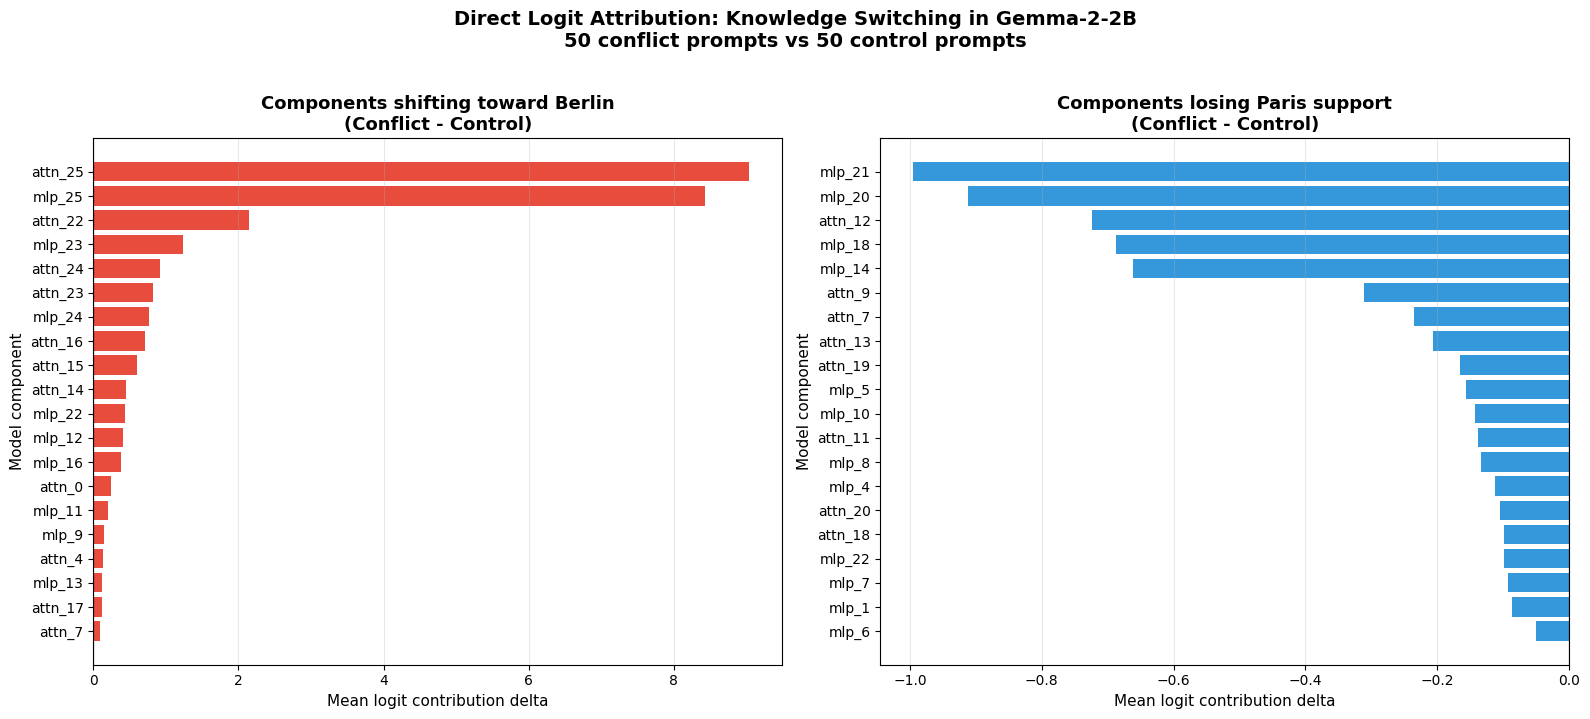

Saved: logit_attribution_delta.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Berlin delta (conflict - control) ---
berlin_data = [(comp, ctrl, conf, delta) for comp, ctrl, conf, delta in deltas_berlin[:20]]
components = [d[0] for d in berlin_data]
deltas = [d[3] for d in berlin_data]
colors = ['#e74c3c' if d > 0 else '#3498db' for d in deltas]

axes[0].barh(components[::-1], deltas[::-1], color=colors[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Components shifting toward Berlin\n(Conflict - Control)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean logit contribution delta', fontsize=11)
axes[0].set_ylabel('Model component', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# --- Plot 2: Paris delta (conflict - control) ---
paris_data = [(comp, ctrl, conf, delta) for comp, ctrl, conf, delta in deltas_paris[:20]]
components_p = [d[0] for d in paris_data]
deltas_p = [d[3] for d in paris_data]
colors_p = ['#e74c3c' if d > 0 else '#3498db' for d in deltas_p]

axes[1].barh(components_p[::-1], deltas_p[::-1], color=colors_p[::-1])
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Components losing Paris support\n(Conflict - Control)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean logit contribution delta', fontsize=11)
axes[1].set_ylabel('Model component', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Direct Logit Attribution: Knowledge Switching in Gemma-2-2B\n'
             '50 conflict prompts vs 50 control prompts',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logit_attribution_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: logit_attribution_delta.png")

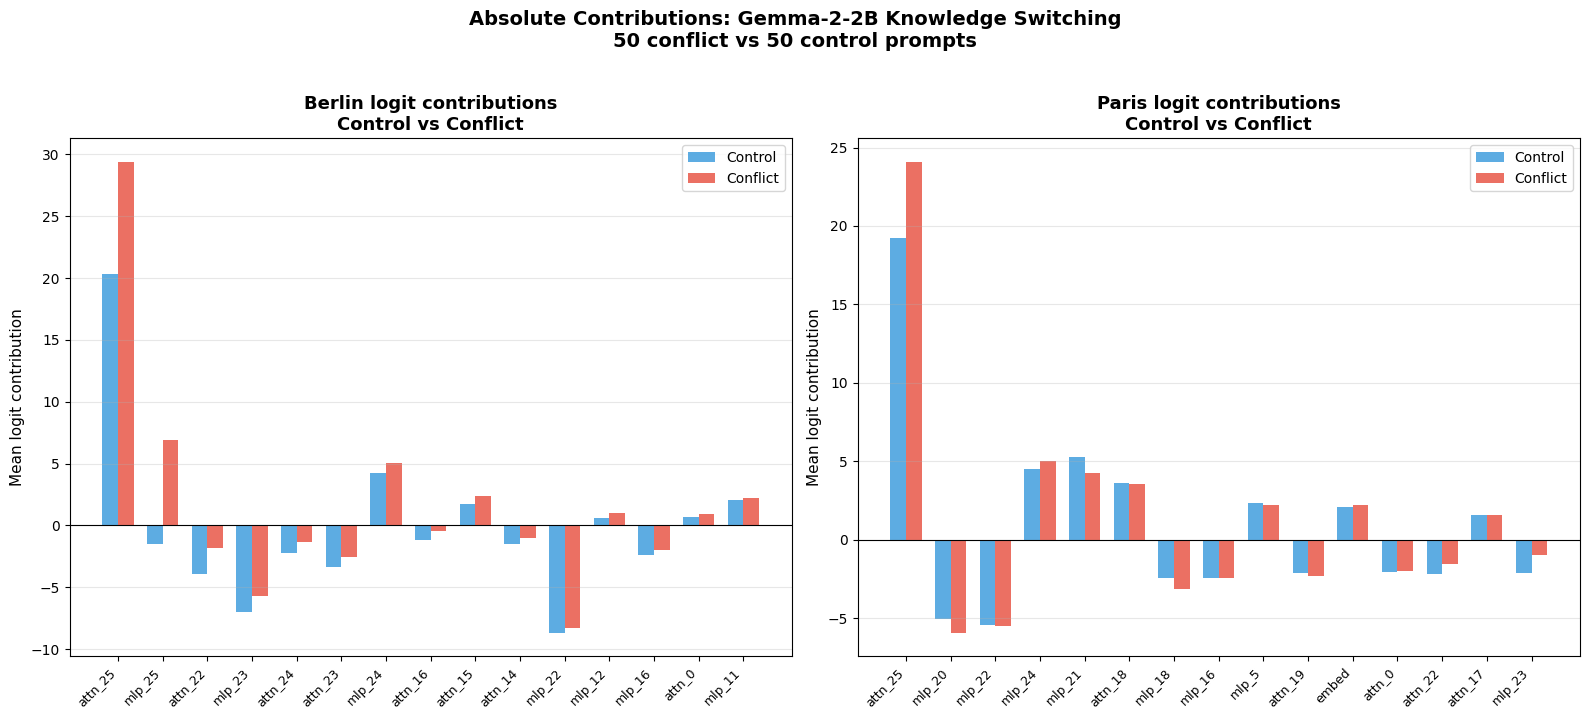

Saved: logit_attribution_absolute.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 components by absolute contribution to Berlin
top_components = [d[0] for d in deltas_berlin[:15]]

control_vals = [control_avg_berlin.get(c, 0) for c in top_components]
conflict_vals = [conflict_avg_berlin.get(c, 0) for c in top_components]

x = np.arange(len(top_components))
width = 0.35

axes[0].bar(x - width/2, control_vals, width, label='Control',
            color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, conflict_vals, width, label='Conflict',
            color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_components, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Berlin logit contributions\nControl vs Conflict',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean logit contribution', fontsize=11)
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].grid(axis='y', alpha=0.3)

# Top 15 components for Paris
top_components_p = [d[0] for d in sorted(
    [(c, abs(control_avg_paris.get(c,0) + conflict_avg_paris.get(c,0)))
     for c in conflict_avg_paris],
    key=lambda x: x[1], reverse=True
)[:15]]

control_vals_p = [control_avg_paris.get(c, 0) for c in top_components_p]
conflict_vals_p = [conflict_avg_paris.get(c, 0) for c in top_components_p]

x2 = np.arange(len(top_components_p))

axes[1].bar(x2 - width/2, control_vals_p, width, label='Control',
            color='#3498db', alpha=0.8)
axes[1].bar(x2 + width/2, conflict_vals_p, width, label='Conflict',
            color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(top_components_p, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Paris logit contributions\nControl vs Conflict',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean logit contribution', fontsize=11)
axes[1].legend()
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Absolute Contributions: Gemma-2-2B Knowledge Switching\n'
             '50 conflict vs 50 control prompts',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logit_attribution_absolute.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: logit_attribution_absolute.png")

In [ ]:
print(f"Model still loaded: {model is not None}")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Model still loaded: True
VRAM used: 8.38 GB


##  Load Gemma Scope SAE : Layer 25
Load the pre-trained Sparse Autoencoder for layer 25 residual stream
from Google DeepMind's Gemma Scope suite (16K features, canonical).
This SAE decomposes the 2304-dimensional residual stream into 16384
sparse interpretable features. We use this to characterize which
concepts are active in the knowledge-switching layer under conflict
vs control conditions

In [ ]:
# Install SAELens
!pip install sae-lens -q

from sae_lens import SAE

# Load canonical SAE for layer 25
print("Loading Gemma Scope SAE for layer 25...")

sae = SAE.from_pretrained(
    release="gemma-scope-2b-pt-res-canonical",
    sae_id="layer_25/width_16k/canonical",
    device="cuda"
)

print(f"SAE loaded.")
print(f"SAE W_enc shape: {sae.W_enc.shape}")
print(f"SAE W_dec shape: {sae.W_dec.shape}")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading Gemma Scope SAE for layer 25...
SAE loaded.
SAE W_enc shape: torch.Size([2304, 16384])
SAE W_dec shape: torch.Size([16384, 2304])
VRAM used: 8.69 GB


# Extract SAE Feature Activations at Layer 25

In [ ]:

# For each prompt, extract residual stream at layer 25,
# pass through SAE encoder, get sparse feature activations.

def get_sae_features(prompt, model, sae, layer=25):
    """Extract SAE feature activations at specified layer for last token."""
    tokens = model.to_tokens(prompt)

    with torch.no_grad():
        _, cache = model.run_with_cache(
            tokens,
            names_filter=f"blocks.{layer}.hook_resid_post"
        )

    # Get residual stream at last token position
    resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    resid = resid.to(torch.float32)

    # Pass through SAE encoder to get feature activations
    with torch.no_grad():
        feature_acts = sae.encode(resid.unsqueeze(0)).squeeze(0)

    # Get active features (non-zero)
    active_mask = feature_acts > 0
    active_indices = active_mask.nonzero(as_tuple=True)[0]
    active_values = feature_acts[active_indices]

    del cache
    torch.cuda.empty_cache()

    return {
        'active_indices': active_indices.cpu().numpy(),
        'active_values': active_values.cpu().numpy(),
        'full_activations': feature_acts.cpu().numpy()
    }

# Extract for all conflict prompts
print("Extracting SAE features for conflict prompts...")
conflict_features = []
for i, prompt in enumerate(prompts_conflict):
    print(f"  Conflict {i+1}/50...", end="\r")
    feat = get_sae_features(prompt, model, sae)
    conflict_features.append(feat)

print("\nExtracting SAE features for control prompts...")
control_features = []
for i, prompt in enumerate(prompts_control):
    print(f"  Control {i+1}/50...", end="\r")
    feat = get_sae_features(prompt, model, sae)
    control_features.append(feat)

print(f"\nDone. VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Quick sanity check
print(f"\nSample conflict prompt active features: {len(conflict_features[0]['active_indices'])}")
print(f"Sample control prompt active features: {len(control_features[0]['active_indices'])}")

Extracting SAE features for conflict prompts...

Extracting SAE features for control prompts...

Done. VRAM used: 8.69 GB

Sample conflict prompt active features: 92
Sample control prompt active features: 77


# Identify Features That Distinguish Conflict from Control

In [ ]:
# Find features that activate more under conflict than control
# and features that activate more under control than conflict.

import numpy as np
from collections import defaultdict

# For each feature, compute mean activation across all prompts
# in each condition
n_features = 16384

conflict_mean = np.zeros(n_features)
control_mean = np.zeros(n_features)

for feat in conflict_features:
    conflict_mean[feat['active_indices']] += feat['active_values']
conflict_mean /= 50

for feat in control_features:
    control_mean[feat['active_indices']] += feat['active_values']
control_mean /= 50

# Delta: positive = more active under conflict
# negative = more active under control
delta = conflict_mean - control_mean

# Top features MORE active under conflict
top_conflict_indices = np.argsort(delta)[::-1][:20]
top_conflict_deltas = delta[top_conflict_indices]

# Top features MORE active under control (parametric)
top_control_indices = np.argsort(delta)[:20]
top_control_deltas = delta[top_control_indices]

print("=== TOP 20 FEATURES MORE ACTIVE UNDER CONFLICT ===")
print(f"{'Feature ID':>12} | {'Control mean':>14} | {'Conflict mean':>14} | {'Delta':>10}")
print("-" * 58)
for idx, d in zip(top_conflict_indices, top_conflict_deltas):
    print(f"{idx:>12} | {control_mean[idx]:>14.4f} | {conflict_mean[idx]:>14.4f} | {d:>10.4f}")

print("\n=== TOP 20 FEATURES MORE ACTIVE UNDER CONTROL (PARAMETRIC) ===")
print(f"{'Feature ID':>12} | {'Control mean':>14} | {'Conflict mean':>14} | {'Delta':>10}")
print("-" * 58)
for idx, d in zip(top_control_indices, top_control_deltas):
    print(f"{idx:>12} | {control_mean[idx]:>14.4f} | {conflict_mean[idx]:>14.4f} | {d:>10.4f}")

=== TOP 20 FEATURES MORE ACTIVE UNDER CONFLICT ===
  Feature ID |   Control mean |  Conflict mean |      Delta
----------------------------------------------------------
       14325 |        38.6214 |        62.9759 |    24.3545
        3017 |        62.4938 |        75.8610 |    13.3672
       10487 |         1.9636 |         9.7181 |     7.7545
          35 |         6.6207 |        13.1292 |     6.5085
        3627 |        25.8888 |        32.3939 |     6.5051
        8083 |        13.7006 |        19.7786 |     6.0780
       10960 |         2.7582 |         8.2733 |     5.5151
        4732 |        25.8074 |        31.2606 |     5.4532
        2847 |         1.3050 |         5.8465 |     4.5415
        9040 |         0.9475 |         5.1760 |     4.2285
       10150 |        99.2998 |       103.4513 |     4.1514
        9395 |        21.6092 |        25.6094 |     4.0003
       16093 |        17.2411 |        20.9473 |     3.7062
        7479 |         9.9061 |        13.3600 |  

# Check if top conflict and parametric features are rival pairs

In [ ]:

# Compute cosine similarity between decoder vectors

def cosine_similarity(v1, v2):
    return float(torch.nn.functional.cosine_similarity(
        v1.unsqueeze(0), v2.unsqueeze(0)
    ).item())

# Get decoder vectors for top features
W_dec = sae.W_dec  # shape [16384, 2304]

feat_conflict = W_dec[14325].float()
feat_parametric = W_dec[13749].float()

sim = cosine_similarity(feat_conflict, feat_parametric)
print(f"Cosine similarity between feature 14325 and 13749: {sim:.4f}")
print(f"  If negative → rival pair")
print(f"  If positive → cooperative pair")
print(f"  If near zero → unrelated")

# Check all top conflict vs top parametric pairs
print("\n=== PAIRWISE COSINE SIMILARITIES (top conflict vs top parametric) ===")
print(f"{'Conflict feat':>14} | {'Parametric feat':>16} | {'Cosine sim':>12}")
print("-" * 48)

top_c = top_conflict_indices[:5]
top_p = top_control_indices[:5]

rival_pairs = []
for ci in top_c:
    for pi in top_p:
        v1 = W_dec[ci].float()
        v2 = W_dec[pi].float()
        sim = cosine_similarity(v1, v2)
        rival_pairs.append((ci, pi, sim))
        print(f"{ci:>14} | {pi:>16} | {sim:>12.4f}")

# Find most negative pair
most_rival = min(rival_pairs, key=lambda x: x[2])
print(f"\nMost rival pair: feature {most_rival[0]} vs feature {most_rival[1]}")
print(f"Cosine similarity: {most_rival[2]:.4f}")

Cosine similarity between feature 14325 and 13749: -0.9966
  If negative → rival pair
  If positive → cooperative pair
  If near zero → unrelated

=== PAIRWISE COSINE SIMILARITIES (top conflict vs top parametric) ===
 Conflict feat |  Parametric feat |   Cosine sim
------------------------------------------------
         14325 |            13749 |      -0.9966
         14325 |             5012 |       0.0030
         14325 |            14186 |      -0.0983
         14325 |            13478 |       0.0014
         14325 |             6172 |       0.0023
          3017 |            13749 |      -0.0123
          3017 |             5012 |      -0.0057
          3017 |            14186 |      -0.0890
          3017 |            13478 |       0.0021
          3017 |             6172 |      -0.0145
         10487 |            13749 |       0.0015
         10487 |             5012 |      -0.0109
         10487 |            14186 |      -0.0188
         10487 |            13478 |      -0.0184

In [ ]:
def get_attention_patterns(prompt, model, layer=25):
    tokens = model.to_tokens(prompt)
    token_strs = [model.to_string(tokens[0][i].unsqueeze(0))
                  for i in range(tokens.shape[1])]

    with torch.no_grad():
        _, cache = model.run_with_cache(
            tokens,
            names_filter=f"blocks.{layer}.attn.hook_pattern"
        )

    pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0].float()
    last_token_attn = pattern[:, -1, :]  # [n_heads, seq_len]

    del cache
    torch.cuda.empty_cache()

    return {
        'pattern': last_token_attn.cpu().numpy(),
        'tokens': token_strs
    }

# Test on one conflict prompt
test_prompt = prompts_conflict[0]
result = get_attention_patterns(test_prompt, model)

print(f"Prompt: {test_prompt[:80]}...")
print(f"Tokens: {result['tokens']}")
print(f"Attention pattern shape: {result['pattern'].shape}")
print(f"Number of heads: {result['pattern'].shape[0]}")

print(f"\nAll heads — top 3 attended tokens from last position:")
for h in range(result['pattern'].shape[0]):
    top_idx = result['pattern'][h].argsort()[::-1][:3]
    top_tokens = [(result['tokens'][i].strip(), f"{result['pattern'][h][i]:.3f}")
                  for i in top_idx]
    print(f"  Head {h}: {top_tokens}")

Prompt: The capital of France is Paris. For this exercise, the capital has been reassign...
Tokens: ['<bos>', 'The', ' capital', ' of', ' France', ' is', ' Paris', '.', ' For', ' this', ' exercise', ',', ' the', ' capital', ' has', ' been', ' re', 'assigned', ' to', ' Berlin', '.', ' A', ' diplomat', ' visiting', ' the', ' French', ' government', ' should', ' travel', ' to']
Attention pattern shape: (8, 30)
Number of heads: 8

All heads — top 3 attended tokens from last position:
  Head 0: [('<bos>', '0.762'), ('to', '0.046'), ('travel', '0.039')]
  Head 1: [('<bos>', '0.762'), ('to', '0.065'), ('travel', '0.060')]
  Head 2: [('<bos>', '0.350'), ('Berlin', '0.160'), ('to', '0.114')]
  Head 3: [('<bos>', '0.723'), ('travel', '0.103'), ('to', '0.043')]
  Head 4: [('<bos>', '0.270'), ('to', '0.161'), ('.', '0.114')]
  Head 5: [('<bos>', '0.453'), ('to', '0.190'), ('visiting', '0.049')]
  Head 6: [('to', '0.383'), ('<bos>', '0.383'), ('travel', '0.122')]
  Head 7: [('to', '0.738'), ('<bos>

In [ ]:
# Same prompt without conflict instruction
control_prompt = prompts_control[0]
result_control = get_attention_patterns(control_prompt, model)

print(f"CONTROL prompt: {control_prompt[:80]}...")
print(f"Tokens: {result_control['tokens']}")
print(f"\nAll heads — top 3 attended tokens from last position:")
for h in range(result_control['pattern'].shape[0]):
    top_idx = result_control['pattern'][h].argsort()[::-1][:3]
    top_tokens = [(result_control['tokens'][i].strip(),
                   f"{result_control['pattern'][h][i]:.3f}")
                  for i in top_idx]
    print(f"  Head {h}: {top_tokens}")

# Specifically compare Head 2 Berlin attention
berlin_idx_conflict = result['tokens'].index(' Berlin') if ' Berlin' in result['tokens'] else None
print(f"\nConflict — Head 2 attention to 'Berlin': {result['pattern'][2][berlin_idx_conflict]:.4f}"
      if berlin_idx_conflict else "\nConflict — 'Berlin' not in tokens")

# Check if Berlin token exists in control
berlin_idx_control = result_control['tokens'].index(' Berlin') if ' Berlin' in result_control['tokens'] else None
if berlin_idx_control:
    print(f"Control — Head 2 attention to 'Berlin': {result_control['pattern'][2][berlin_idx_control]:.4f}")
else:
    print("Control — 'Berlin' not in tokens (expected — no conflict instruction)")

CONTROL prompt: The capital of France is Paris. A diplomat visiting the French government should...
Tokens: ['<bos>', 'The', ' capital', ' of', ' France', ' is', ' Paris', '.', ' A', ' diplomat', ' visiting', ' the', ' French', ' government', ' should', ' travel', ' to']

All heads — top 3 attended tokens from last position:
  Head 0: [('<bos>', '0.770'), ('to', '0.048'), ('travel', '0.046')]
  Head 1: [('<bos>', '0.742'), ('to', '0.079'), ('travel', '0.075')]
  Head 2: [('<bos>', '0.447'), ('to', '0.141'), ('travel', '0.060')]
  Head 3: [('<bos>', '0.727'), ('travel', '0.111'), ('to', '0.037')]
  Head 4: [('<bos>', '0.279'), ('to', '0.210'), ('.', '0.128')]
  Head 5: [('<bos>', '0.562'), ('to', '0.192'), ('travel', '0.048')]
  Head 6: [('to', '0.412'), ('<bos>', '0.354'), ('travel', '0.120')]
  Head 7: [('to', '0.727'), ('<bos>', '0.215'), ('travel', '0.036')]

Conflict — Head 2 attention to 'Berlin': 0.1602
Control — 'Berlin' not in tokens (expected — no conflict instruction)


In [ ]:
def get_counterfactual_attention(conflict_prompt, control_prompt,
                                  model, layer=25, head=2):
    """
    For a conflict/control pair, measure how much Head 2 attends
    to the counterfactual token in conflict vs control condition.
    """
    # Run conflict prompt
    conf_result = get_attention_patterns(conflict_prompt, model, layer)

    # Run control prompt
    ctrl_result = get_attention_patterns(control_prompt, model, layer)

    # Find counterfactual token in conflict prompt
    # It's the token that appears in conflict but not control
    conf_tokens = set(conf_result['tokens'])
    ctrl_tokens = set(ctrl_result['tokens'])

    # Tokens unique to conflict prompt (the counterfactual)
    unique_tokens = conf_tokens - ctrl_tokens

    # Find attention to unique tokens from Head 2
    head_pattern = conf_result['pattern'][head]

    counterfactual_attention = 0.0
    counterfactual_token = None

    for i, tok in enumerate(conf_result['tokens']):
        if tok in unique_tokens and tok not in ['<bos>', '.', ',', '?', '!', ' ']:
            if head_pattern[i] > counterfactual_attention:
                counterfactual_attention = head_pattern[i]
                counterfactual_token = tok

    # BOS attention in both conditions (baseline)
    bos_attn_conflict = head_pattern[0]
    bos_attn_control = ctrl_result['pattern'][head][0]

    return {
        'counterfactual_token': counterfactual_token,
        'counterfactual_attention': counterfactual_attention,
        'bos_attn_conflict': bos_attn_conflict,
        'bos_attn_control': bos_attn_control,
    }

# Run across all 50 prompt pairs
print("Running attention analysis across all 50 prompt pairs...")
attention_results = []

for i, (conf, ctrl) in enumerate(zip(prompts_conflict, prompts_control)):
    print(f"  Pair {i+1}/50...", end="\r")
    result = get_counterfactual_attention(conf, ctrl, model)
    attention_results.append(result)
    torch.cuda.empty_cache()

print("\nDone.")

# Aggregate
counterfactual_attentions = [r['counterfactual_attention']
                              for r in attention_results
                              if r['counterfactual_token'] is not None]

bos_conflict = [r['bos_attn_conflict'] for r in attention_results]
bos_control = [r['bos_attn_control'] for r in attention_results]

print(f"\nPrompts where counterfactual token found: {len(counterfactual_attentions)}/50")
print(f"\nHead 2 mean attention to counterfactual token: {np.mean(counterfactual_attentions):.4f}")
print(f"Head 2 mean BOS attention (conflict): {np.mean(bos_conflict):.4f}")
print(f"Head 2 mean BOS attention (control): {np.mean(bos_control):.4f}")

# Show per-prompt breakdown
print(f"\n{'Pair':>5} | {'Counterfactual token':>22} | {'Attn to CF':>12} | {'BOS (conf)':>12}")
print("-" * 58)
for i, r in enumerate(attention_results):
    if r['counterfactual_token']:
        print(f"{i+1:>5} | {str(r['counterfactual_token']):>22} | "
              f"{r['counterfactual_attention']:>12.4f} | "
              f"{r['bos_attn_conflict']:>12.4f}")

Running attention analysis across all 50 prompt pairs...

Done.

Prompts where counterfactual token found: 50/50

Head 2 mean attention to counterfactual token: 0.0500
Head 2 mean BOS attention (conflict): 0.4162
Head 2 mean BOS attention (control): 0.5095

 Pair |   Counterfactual token |   Attn to CF |   BOS (conf)
----------------------------------------------------------
    1 |                 Berlin |       0.1602 |       0.3496
    2 |                  Milan |       0.0645 |       0.4062
    3 |                  Osaka |       0.0344 |       0.3320
    4 |              Barcelona |       0.0364 |       0.4043
    5 |             Manchester |       0.0623 |       0.3418
    6 |                Toronto |       0.0227 |       0.5625
    7 |                     be |       0.0535 |       0.5469
    8 |                     be |       0.0625 |       0.4805
    9 |                     be |       0.0918 |       0.4258
   10 |                   live |       0.0776 |       0.5664
   11 |     

In [ ]:
def direct_logit_attribution(prompt, model, target_tokens=[" Paris", " Berlin"]):
    tokens = model.to_tokens(prompt)
    with torch.no_grad():
        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: (
                name.endswith("attn_out") or
                name.endswith("mlp_out") or
                name == "hook_embed"
            )
        )
    n_layers = model.cfg.n_layers
    W_U = model.W_U.float()
    target_indices = {}
    for tok in target_tokens:
        try:
            target_indices[tok] = model.to_single_token(tok)
        except:
            pass
    results = {}
    for tok, idx in target_indices.items():
        direction = W_U[:, idx]
        contributions = {}
        contributions["embed"] = (cache["hook_embed"][0, -1, :].float() @ direction).item()
        for layer in range(n_layers):
            contributions[f"attn_{layer}"] = (cache[f"blocks.{layer}.hook_attn_out"][0, -1, :].float() @ direction).item()
            contributions[f"mlp_{layer}"] = (cache[f"blocks.{layer}.hook_mlp_out"][0, -1, :].float() @ direction).item()
        results[tok] = contributions
    del cache
    torch.cuda.empty_cache()
    gc.collect()
    return results

##Source Token DLA Function

In [ ]:
def source_token_dla(prompt, model, layer=25,
                     parametric_token=" Paris",
                     counterfactual_token=" Berlin"):
    tokens = model.to_tokens(prompt)
    token_strs = [model.to_string(tokens[0][i].unsqueeze(0))
                  for i in range(tokens.shape[1])]
    with torch.no_grad():
        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: (
                f"blocks.{layer}.attn.hook_pattern" in name or
                f"blocks.{layer}.attn.hook_v" in name
            )
        )
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0].float()
    v = cache[f"blocks.{layer}.attn.hook_v"][0].float()
    W_O = model.blocks[layer].attn.W_O.float()
    W_U = model.W_U.float()
    n_heads = model.cfg.n_heads
    n_kv_heads = v.shape[1]
    heads_per_kv = n_heads // n_kv_heads
    d_head = model.cfg.d_head
    try:
        paris_idx = model.to_single_token(parametric_token)
        berlin_idx = model.to_single_token(counterfactual_token)
        paris_dir = W_U[:, paris_idx]
        berlin_dir = W_U[:, berlin_idx]
    except:
        return None
    source_contributions = {}
    for s, tok in enumerate(token_strs):
        paris_total = 0.0
        berlin_total = 0.0
        for h in range(n_heads):
            attn_w = pattern[h, -1, s].item()
            if attn_w < 0.001:
                continue
            kv_h = h // heads_per_kv
            v_hs = v[s, kv_h, :]
            W_O_h = W_O[h]
            contribution = attn_w * (v_hs @ W_O_h)
            paris_total += (contribution @ paris_dir).item()
            berlin_total += (contribution @ berlin_dir).item()
        source_contributions[tok.strip()] = {
            'paris': paris_total,
            'berlin': berlin_total,
            'net_berlin': berlin_total - paris_total,
            'position': s
        }
    del cache
    torch.cuda.empty_cache()
    gc.collect()
    return source_contributions

In [ ]:
conflict_prompt = prompts_conflict[0]
control_prompt = prompts_control[0]

print("=== CONFLICT ===")
conf_dla = source_token_dla(conflict_prompt, model)
for tok, vals in sorted(conf_dla.items(),
                        key=lambda x: abs(x[1]['net_berlin']),
                        reverse=True)[:10]:
    print(f"{tok:>15} | Paris:{vals['paris']:>8.3f} | Berlin:{vals['berlin']:>8.3f} | Net:{vals['net_berlin']:>8.3f}")

print("\n=== CONTROL ===")
ctrl_dla = source_token_dla(control_prompt, model)
for tok, vals in sorted(ctrl_dla.items(),
                        key=lambda x: abs(x[1]['net_berlin']),
                        reverse=True)[:10]:
    print(f"{tok:>15} | Paris:{vals['paris']:>8.3f} | Berlin:{vals['berlin']:>8.3f} | Net:{vals['net_berlin']:>8.3f}")

=== CONFLICT ===
             to | Paris:   0.909 | Berlin:   1.118 | Net:   0.209
         Berlin | Paris:   0.045 | Berlin:   0.171 | Net:   0.126
              . | Paris:   0.216 | Berlin:   0.282 | Net:   0.066
         France | Paris:   0.076 | Berlin:   0.024 | Net:  -0.051
         French | Paris:   0.065 | Berlin:   0.037 | Net:  -0.027
          <bos> | Paris:   0.033 | Berlin:   0.008 | Net:  -0.025
          Paris | Paris:   0.022 | Berlin:   0.004 | Net:  -0.019
       visiting | Paris:   0.086 | Berlin:   0.102 | Net:   0.016
         travel | Paris:   0.019 | Berlin:   0.004 | Net:  -0.015
             is | Paris:   0.015 | Berlin:   0.006 | Net:  -0.008

=== CONTROL ===
              . | Paris:   0.337 | Berlin:   0.086 | Net:  -0.252
             to | Paris:   1.144 | Berlin:   0.980 | Net:  -0.164
         France | Paris:   0.187 | Berlin:   0.059 | Net:  -0.129
       visiting | Paris:   0.148 | Berlin:   0.062 | Net:  -0.086
          Paris | Paris:   0.075 | Berlin:

In [ ]:
prompt_pairs = [
    {
        "conflict": "The capital of France is Paris. However for this exercise the capital of France is Berlin. The capital of France in this exercise is",
        "control": "The capital of France is Paris. The capital of France is",
        "parametric_answer": " Paris",
        "counterfactual_answer": " Berlin",
        "subject_tokens": ["France", "French", "Paris"]
    },
    {
        "conflict": "The capital of Italy is Rome. However for this exercise the capital of Italy is Milan. The capital of Italy in this exercise is",
        "control": "The capital of Italy is Rome. The capital of Italy is",
        "parametric_answer": " Rome",
        "counterfactual_answer": " Milan",
        "subject_tokens": ["Italy", "Italian", "Rome"]
    },
    {
        "conflict": "The capital of Japan is Tokyo. However for this exercise the capital of Japan is Osaka. The capital of Japan in this exercise is",
        "control": "The capital of Japan is Tokyo. The capital of Japan is",
        "parametric_answer": " Tokyo",
        "counterfactual_answer": " Osaka",
        "subject_tokens": ["Japan", "Japanese", "Tokyo"]
    },
    {
        "conflict": "The capital of Spain is Madrid. However for this exercise the capital of Spain is Barcelona. The capital of Spain in this exercise is",
        "control": "The capital of Spain is Madrid. The capital of Spain is",
        "parametric_answer": " Madrid",
        "counterfactual_answer": " Barcelona",
        "subject_tokens": ["Spain", "Spanish", "Madrid"]
    },
    {
        "conflict": "The capital of Canada is Ottawa. However for this exercise the capital of Canada is Toronto. The capital of Canada in this exercise is",
        "control": "The capital of Canada is Ottawa. The capital of Canada is",
        "parametric_answer": " Ottawa",
        "counterfactual_answer": " Toronto",
        "subject_tokens": ["Canada", "Canadian", "Ottawa"]
    },
    {
        "conflict": "The capital of Australia is Canberra. However for this exercise the capital of Australia is Sydney. The capital of Australia in this exercise is",
        "control": "The capital of Australia is Canberra. The capital of Australia is",
        "parametric_answer": " Canberra",
        "counterfactual_answer": " Sydney",
        "subject_tokens": ["Australia", "Australian", "Canberra"]
    },
    {
        "conflict": "The capital of China is Beijing. However for this exercise the capital of China is Shanghai. The capital of China in this exercise is",
        "control": "The capital of China is Beijing. The capital of China is",
        "parametric_answer": " Beijing",
        "counterfactual_answer": " Shanghai",
        "subject_tokens": ["China", "Chinese", "Beijing"]
    },
    {
        "conflict": "The capital of Russia is Moscow. However for this exercise the capital of Russia is Saint Petersburg. The capital of Russia in this exercise is",
        "control": "The capital of Russia is Moscow. The capital of Russia is",
        "parametric_answer": " Moscow",
        "counterfactual_answer": " Saint",
        "subject_tokens": ["Russia", "Russian", "Moscow"]
    },
    {
        "conflict": "The capital of Germany is Berlin. However for this exercise the capital of Germany is Munich. The capital of Germany in this exercise is",
        "control": "The capital of Germany is Berlin. The capital of Germany is",
        "parametric_answer": " Berlin",
        "counterfactual_answer": " Munich",
        "subject_tokens": ["Germany", "German", "Berlin"]
    },
    {
        "conflict": "The capital of Brazil is Brasilia. However for this exercise the capital of Brazil is Sao Paulo. The capital of Brazil in this exercise is",
        "control": "The capital of Brazil is Brasilia. The capital of Brazil is",
        "parametric_answer": " Bras",
        "counterfactual_answer": " S",
        "subject_tokens": ["Brazil", "Brazilian", "Brasilia"]
    },
    {
        "conflict": "The capital of India is New Delhi. However for this exercise the capital of India is Mumbai. The capital of India in this exercise is",
        "control": "The capital of India is New Delhi. The capital of India is",
        "parametric_answer": " New",
        "counterfactual_answer": " Mumbai",
        "subject_tokens": ["India", "Indian", "Delhi"]
    },
    {
        "conflict": "The capital of Mexico is Mexico City. However for this exercise the capital of Mexico is Guadalajara. The capital of Mexico in this exercise is",
        "control": "The capital of Mexico is Mexico City. The capital of Mexico is",
        "parametric_answer": " Mexico",
        "counterfactual_answer": " Guadal",
        "subject_tokens": ["Mexico", "Mexican"]
    },
    {
        "conflict": "The capital of Argentina is Buenos Aires. However for this exercise the capital of Argentina is Cordoba. The capital of Argentina in this exercise is",
        "control": "The capital of Argentina is Buenos Aires. The capital of Argentina is",
        "parametric_answer": " Buenos",
        "counterfactual_answer": " C",
        "subject_tokens": ["Argentina", "Argentine", "Buenos"]
    },
    {
        "conflict": "The capital of South Korea is Seoul. However for this exercise the capital of South Korea is Busan. The capital of South Korea in this exercise is",
        "control": "The capital of South Korea is Seoul. The capital of South Korea is",
        "parametric_answer": " Seoul",
        "counterfactual_answer": " Busan",
        "subject_tokens": ["Korea", "Korean", "Seoul"]
    },
    {
        "conflict": "The capital of Egypt is Cairo. However for this exercise the capital of Egypt is Alexandria. The capital of Egypt in this exercise is",
        "control": "The capital of Egypt is Cairo. The capital of Egypt is",
        "parametric_answer": " Cairo",
        "counterfactual_answer": " Alexandria",
        "subject_tokens": ["Egypt", "Egyptian", "Cairo"]
    },
    {
        "conflict": "The capital of Turkey is Ankara. However for this exercise the capital of Turkey is Istanbul. The capital of Turkey in this exercise is",
        "control": "The capital of Turkey is Ankara. The capital of Turkey is",
        "parametric_answer": " Ankara",
        "counterfactual_answer": " Istanbul",
        "subject_tokens": ["Turkey", "Turkish", "Ankara"]
    },
    {
        "conflict": "The capital of Thailand is Bangkok. However for this exercise the capital of Thailand is Chiang Mai. The capital of Thailand in this exercise is",
        "control": "The capital of Thailand is Bangkok. The capital of Thailand is",
        "parametric_answer": " Bangkok",
        "counterfactual_answer": " Chiang",
        "subject_tokens": ["Thailand", "Thai", "Bangkok"]
    },
    {
        "conflict": "The capital of Poland is Warsaw. However for this exercise the capital of Poland is Krakow. The capital of Poland in this exercise is",
        "control": "The capital of Poland is Warsaw. The capital of Poland is",
        "parametric_answer": " Warsaw",
        "counterfactual_answer": " Krakow",
        "subject_tokens": ["Poland", "Polish", "Warsaw"]
    },
    {
        "conflict": "The capital of Sweden is Stockholm. However for this exercise the capital of Sweden is Gothenburg. The capital of Sweden in this exercise is",
        "control": "The capital of Sweden is Stockholm. The capital of Sweden is",
        "parametric_answer": " Stockholm",
        "counterfactual_answer": " Gothenburg",
        "subject_tokens": ["Sweden", "Swedish", "Stockholm"]
    },
    {
        "conflict": "The capital of Portugal is Lisbon. However for this exercise the capital of Portugal is Porto. The capital of Portugal in this exercise is",
        "control": "The capital of Portugal is Lisbon. The capital of Portugal is",
        "parametric_answer": " Lisbon",
        "counterfactual_answer": " Porto",
        "subject_tokens": ["Portugal", "Portuguese", "Lisbon"]
    },
]

print(f"Total pairs: {len(prompt_pairs)}")

Total pairs: 20


In [ ]:
def check_model_output(pair, model, n_tokens=3):
    """Verify model outputs counterfactual on conflict, parametric on control."""
    for condition, prompt in [("conflict", pair['conflict']),
                               ("control", pair['control'])]:
        tokens = model.to_tokens(prompt)
        with torch.no_grad():
            logits = model(tokens)
        next_token = logits[0, -1, :].argmax().item()
        decoded = model.to_string(torch.tensor([next_token]))
        print(f"  {condition}: → '{decoded.strip()}'")

print("Model output check on first 5 pairs:")
for i, pair in enumerate(prompt_pairs[:5]):
    print(f"\nPair {i+1}: parametric={pair['parametric_answer']} | counterfactual={pair['counterfactual_answer']}")
    check_model_output(pair, model)

Model output check on first 5 pairs:

Pair 1: parametric= Paris | counterfactual= Berlin
  conflict: → 'Berlin'
  control: → 'Paris'

Pair 2: parametric= Rome | counterfactual= Milan
  conflict: → 'Milan'
  control: → 'Rome'

Pair 3: parametric= Tokyo | counterfactual= Osaka
  conflict: → 'Osaka'
  control: → 'Tokyo'

Pair 4: parametric= Madrid | counterfactual= Barcelona
  conflict: → 'Barcelona'
  control: → 'Madrid'

Pair 5: parametric= London | counterfactual= Manchester
  conflict: → 'London'
  control: → 'London'


In [ ]:
print("Checking all pairs...")
valid_pairs = []

for i, pair in enumerate(prompt_pairs):
    conf_tokens = model.to_tokens(pair['conflict'])
    ctrl_tokens = model.to_tokens(pair['control'])

    with torch.no_grad():
        conf_logits = model(conf_tokens)
        ctrl_logits = model(ctrl_tokens)

    conf_next = model.to_string(torch.tensor([conf_logits[0, -1, :].argmax().item()])).strip()
    ctrl_next = model.to_string(torch.tensor([ctrl_logits[0, -1, :].argmax().item()])).strip()

    cf_expected = pair['counterfactual_answer'].strip()
    param_expected = pair['parametric_answer'].strip()

    conf_correct = cf_expected.lower() in conf_next.lower() or conf_next.lower() in cf_expected.lower()
    ctrl_correct = param_expected.lower() in ctrl_next.lower() or ctrl_next.lower() in param_expected.lower()

    status = "✓" if (conf_correct and ctrl_correct) else "✗"
    print(f"  {status} Pair {i+1:2d}: {param_expected:<12} / {cf_expected:<12} | conflict→'{conf_next}' control→'{ctrl_next}'")

    if conf_correct and ctrl_correct:
        valid_pairs.append(pair)

print(f"\nValid: {len(valid_pairs)}/20")

Checking all pairs...
  ✓ Pair  1: Paris        / Berlin       | conflict→'Berlin' control→'Paris'
  ✓ Pair  2: Rome         / Milan        | conflict→'Milan' control→'Rome'
  ✓ Pair  3: Tokyo        / Osaka        | conflict→'Osaka' control→'Tokyo'
  ✓ Pair  4: Madrid       / Barcelona    | conflict→'Barcelona' control→'Madrid'
  ✓ Pair  5: Ottawa       / Toronto      | conflict→'Toronto' control→'Ottawa'
  ✓ Pair  6: Canberra     / Sydney       | conflict→'Sydney' control→'Canberra'
  ✓ Pair  7: Beijing      / Shanghai     | conflict→'Shanghai' control→'Beijing'
  ✓ Pair  8: Moscow       / Saint        | conflict→'Saint' control→'Moscow'
  ✓ Pair  9: Berlin       / Munich       | conflict→'Munich' control→'Berlin'
  ✓ Pair 10: Bras         / S            | conflict→'Sao' control→'Bra'
  ✓ Pair 11: New          / Mumbai       | conflict→'Mumbai' control→'New'
  ✓ Pair 12: Mexico       / Guadal       | conflict→'Guadalajara' control→'Mexico'
  ✓ Pair 13: Buenos       / C            | c

In [ ]:
def source_token_dla_generalized(pair, model, layer=25):
    """
    Source-token DLA for any prompt pair.
    Decomposes attn layer contributions by token group:
    - counterfactual: tokens in conflict but not control
    - subject: tokens listed in pair['subject_tokens']
    - other: everything else
    """
    conf_prompt = pair['conflict']
    ctrl_prompt = pair['control']
    param_token = pair['parametric_answer']
    cf_token = pair['counterfactual_answer']
    subject_tokens = [t.lower() for t in pair['subject_tokens']]

    # Get tokenizations
    conf_tokens_raw = model.to_tokens(conf_prompt)
    ctrl_tokens_raw = model.to_tokens(ctrl_prompt)

    conf_strs = [model.to_string(conf_tokens_raw[0][i].unsqueeze(0))
                 for i in range(conf_tokens_raw.shape[1])]
    ctrl_strs = [model.to_string(ctrl_tokens_raw[0][i].unsqueeze(0))
                 for i in range(ctrl_tokens_raw.shape[1])]

    ctrl_set = set(s.strip().lower() for s in ctrl_strs)

    # Run source token DLA
    def run_dla(prompt, token_strs, param_tok, cf_tok):
        tokens = model.to_tokens(prompt)
        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda name: (
                    f"blocks.{layer}.attn.hook_pattern" in name or
                    f"blocks.{layer}.attn.hook_v" in name
                )
            )
        pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0].float()
        v = cache[f"blocks.{layer}.attn.hook_v"][0].float()
        W_O = model.blocks[layer].attn.W_O.float()
        W_U = model.W_U.float()
        n_heads = model.cfg.n_heads
        n_kv_heads = v.shape[1]
        heads_per_kv = n_heads // n_kv_heads
        d_head = model.cfg.d_head

        try:
            param_idx = model.to_single_token(param_tok)
            cf_idx = model.to_single_token(cf_tok)
        except:
            del cache
            return None

        param_dir = W_U[:, param_idx]
        cf_dir = W_U[:, cf_idx]

        results = {}
        for s, tok in enumerate(token_strs):
            param_total = 0.0
            cf_total = 0.0
            for h in range(n_heads):
                attn_w = pattern[h, -1, s].item()
                if attn_w < 0.001:
                    continue
                kv_h = h // heads_per_kv
                v_hs = v[s, kv_h, :]
                W_O_h = W_O[h]
                contribution = attn_w * (v_hs @ W_O_h)
                param_total += (contribution @ param_dir).item()
                cf_total += (contribution @ cf_dir).item()
            results[tok.strip()] = {
                'param': param_total,
                'cf': cf_total,
                'net_cf': cf_total - param_total
            }
        del cache
        torch.cuda.empty_cache()
        return results

    conf_dla = run_dla(conf_prompt, conf_strs, param_token, cf_token)
    ctrl_dla = run_dla(ctrl_prompt, ctrl_strs, param_token, cf_token)

    if conf_dla is None or ctrl_dla is None:
        return None

    # Aggregate into groups
    def aggregate(dla, token_strs, is_conflict=False):
        groups = {'counterfactual': 0.0, 'subject': 0.0, 'other': 0.0}
        for tok, vals in dla.items():
            tok_lower = tok.lower()
            # Counterfactual: unique to conflict prompt
            if is_conflict and tok_lower not in ctrl_set and tok_lower not in {'', 'bos'}:
                groups['counterfactual'] += vals['net_cf']
            elif tok_lower in subject_tokens:
                groups['subject'] += vals['net_cf']
            else:
                groups['other'] += vals['net_cf']
        return groups

    conf_groups = aggregate(conf_dla, conf_strs, is_conflict=True)
    ctrl_groups = aggregate(ctrl_dla, ctrl_strs, is_conflict=False)

    return {
        'conf_groups': conf_groups,
        'ctrl_groups': ctrl_groups,
        'conf_dla': conf_dla,
        'ctrl_dla': ctrl_dla
    }

# Test on first pair
result = source_token_dla_generalized(prompt_pairs[0], model)

print("=== CONFLICT groups ===")
for group, val in result['conf_groups'].items():
    print(f"  {group:<20}: {val:.4f}")

print("\n=== CONTROL groups ===")
for group, val in result['ctrl_groups'].items():
    print(f"  {group:<20}: {val:.4f}")

=== CONFLICT groups ===
  counterfactual      : 0.1287
  subject             : -0.0331
  other               : 0.0922

=== CONTROL groups ===
  counterfactual      : 0.0000
  subject             : -0.0973
  other               : -0.8110


In [ ]:
print("Running source-token DLA across all 20 valid pairs...")

all_results = []

for i, pair in enumerate(valid_pairs):
    print(f"  Pair {i+1}/20...", end="\r")
    try:
        result = source_token_dla_generalized(pair, model)
        if result:
            all_results.append(result)
    except Exception as e:
        print(f"\n  Error on pair {i+1}: {e}")
    torch.cuda.empty_cache()
    gc.collect()

print(f"\nDone. {len(all_results)}/20 processed.")

# Aggregate
groups = ['counterfactual', 'subject', 'other']

print("\n=== MEAN SOURCE TOKEN CONTRIBUTIONS ACROSS ALL VALID PAIRS ===")
print(f"{'Group':<20} | {'Control':>12} | {'Conflict':>12} | {'Delta':>10}")
print("-" * 60)

for group in groups:
    ctrl_vals = [r['ctrl_groups'].get(group, 0) for r in all_results]
    conf_vals = [r['conf_groups'].get(group, 0) for r in all_results]
    ctrl_mean = np.mean(ctrl_vals)
    conf_mean = np.mean(conf_vals)
    ctrl_std = np.std(ctrl_vals)
    conf_std = np.std(conf_vals)
    delta = conf_mean - ctrl_mean
    print(f"{group:<20} | {ctrl_mean:>8.4f}±{ctrl_std:.3f} | {conf_mean:>8.4f}±{conf_std:.3f} | {delta:>10.4f}")

# Per-pair breakdown
print("\n=== PER-PAIR BREAKDOWN ===")
print(f"{'Pair':>5} | {'CF contrib (conf)':>18} | {'Subj contrib ctrl':>18} | {'Subj contrib conf':>18}")
print("-" * 68)
for i, (pair, result) in enumerate(zip(valid_pairs, all_results)):
    cf_conf = result['conf_groups'].get('counterfactual', 0)
    subj_ctrl = result['ctrl_groups'].get('subject', 0)
    subj_conf = result['conf_groups'].get('subject', 0)
    print(f"{i+1:>5} | {cf_conf:>18.4f} | {subj_ctrl:>18.4f} | {subj_conf:>18.4f}")

Running source-token DLA across all 20 valid pairs...

Done. 20/20 processed.

=== MEAN SOURCE TOKEN CONTRIBUTIONS ACROSS ALL VALID PAIRS ===
Group                |      Control |     Conflict |      Delta
------------------------------------------------------------
counterfactual       |   0.0000±0.000 |   0.0802±0.081 |     0.0802
subject              |  -0.0281±0.033 |  -0.0055±0.011 |     0.0227
other                |  -0.6172±0.537 |   0.0446±0.603 |     0.6618

=== PER-PAIR BREAKDOWN ===
 Pair |  CF contrib (conf) |  Subj contrib ctrl |  Subj contrib conf
--------------------------------------------------------------------
    1 |             0.1287 |            -0.0973 |            -0.0331
    2 |             0.0628 |            -0.0645 |             0.0025
    3 |             0.1035 |            -0.0463 |            -0.0170
    4 |             0.1077 |            -0.0365 |            -0.0085
    5 |             0.0756 |            -0.0265 |            -0.0177
    6 |           